# TrueType
Vector graphic font file format

## Background
* Always been interested in type setting
* Wrote a small C# program in 2014 for parsing & rasterization

## File format

Consist of various tables. We'll use these today
* `head`- Needed to load `local`
* `maxp` - Contains number of glyphs
* `loca` - Contain byte start/end positions of raw glyph data
* `glyf` - Contain glyph data

Also interesting:
* `kern`
* `fpgm`


In [13]:
from dataclasses import dataclass
import struct

@dataclass
class Table:
    checksum: int
    data: bytes
    
def load_tables(data: bytes, num_tables: int) -> dict[str, Table]:
    tables = {}
    for i in range(num_tables):
        entry = 12 + i * 16
        tag = data[entry:entry+4].decode("ascii")
        checksum, offset, length = struct.unpack_from(">III", data, entry + 4)
        tables[tag] = Table(checksum, data[offset:offset+length])
    return tables

path = "segoeui.ttf"
with open(path, "rb") as f:
    data = f.read()

sf_version, num_tables, *_ = struct.unpack_from(">IHHHH", data, 0)
tables = load_tables(data, num_tables)
for tag, table in tables.items():
    print(f"{tag} {table.checksum:08x}")

DSIG f536db07
GDEF 2e813981
GPOS 283af5ca
GSUB 90e7e2a6
LTSH 274d7b60
MERG 00160001
OS/2 5f623d80
VDMX 76587dd3
cmap d58c1c3f
cvt  7cb55ddd
fpgm bd3c2aff
gasp 001b0023
glyf 2aa6af02
hdmx 74ac25f9
head eb0cd166
hhea 152f1d2d
hmtx c9660403
kern c59bf00a
loca 4e0df380
maxp 19150b2b
name cb273f6f
post ff510077
prep 93ee1eb9


In [54]:
@dataclass
class HeadTable:
    units_per_em: int
    index_to_loc_format: int

@dataclass
class MaxpTable:
    num_glyphs: int

@dataclass
class LocaTable:
    offsets: list[int]

def parse_head(table: Table) -> HeadTable:
    units_per_em = struct.unpack_from(">H", table.data, 18)[0]
    # indexToLocFormat is at byte offset 50 within the head table
    index_to_loc_format = struct.unpack_from(">h", table.data, 50)[0]
    return HeadTable(units_per_em, index_to_loc_format)

def parse_maxp(table: Table) -> MaxpTable:
    num_glyphs = struct.unpack_from(">H", table.data, 4)[0]
    return MaxpTable(num_glyphs)

def parse_loca(table: Table, head: HeadTable, maxp: MaxpTable) -> LocaTable:
    n = maxp.num_glyphs + 1
    if head.index_to_loc_format == 0:
        raw = struct.unpack_from(f">{n}H", table.data, 0)
        offsets = [v * 2 for v in raw]
    else:
        offsets = list(struct.unpack_from(f">{n}I", table.data, 0))
    return LocaTable(offsets)

head = parse_head(tables["head"])
maxp = parse_maxp(tables["maxp"])
loca = parse_loca(tables["loca"], head, maxp)
print(maxp.num_glyphs)
print(len(loca.offsets))

5009
5010


In [50]:
@dataclass
class Point:
    x: int
    y: int
    on_curve: bool

@dataclass
class Contour:
    points: list[Point]

@dataclass
class Glyph:
    x_min: int
    y_min: int
    x_max: int
    y_max: int
    contours: list[Contour]

def parse_glyph(data: bytes, offset: int, num_contours: int, x_min: int, y_min: int, x_max: int, y_max: int) -> Glyph:
    end_pts = struct.unpack_from(f">{num_contours}H", data, offset)
    offset += num_contours * 2

    instruction_length = struct.unpack_from(">H", data, offset)[0]
    offset += 2 + instruction_length

    num_points = end_pts[-1] + 1

    # Parse flags (with repeat)
    ON_CURVE  = 0x01
    X_SHORT   = 0x02
    Y_SHORT   = 0x04
    REPEAT    = 0x08
    X_SAME_OR_POS = 0x10
    Y_SAME_OR_POS = 0x20

    flags = []
    while len(flags) < num_points:
        flag = data[offset]; offset += 1
        flags.append(flag)
        if flag & REPEAT:
            repeat = data[offset]; offset += 1
            flags.extend([flag] * repeat)

    def read_coords(short_bit: int, same_or_pos_bit: int) -> list[int]:
        nonlocal offset
        coords, value = [], 0
        for flag in flags:
            if flag & short_bit:
                delta = data[offset]; offset += 1
                value += delta if (flag & same_or_pos_bit) else -delta
            elif flag & same_or_pos_bit:
                pass  # delta is 0
            else:
                delta = struct.unpack_from(">h", data, offset)[0]; offset += 2
                value += delta
            coords.append(value)
        return coords

    xs = read_coords(X_SHORT, X_SAME_OR_POS)
    ys = read_coords(Y_SHORT, Y_SAME_OR_POS)

    contours = []
    prev_end = -1
    for end in end_pts:
        points = [Point(xs[i], ys[i], bool(flags[i] & ON_CURVE)) for i in range(prev_end + 1, end + 1)]
        contours.append(Contour(points))
        prev_end = end

    return Glyph(x_min, y_min, x_max, y_max, contours)

In [51]:
@dataclass
class Component:
    glyph_index: int
    x: int
    y: int


@dataclass
class CompositeGlyph:
    x_min: int
    y_min: int
    x_max: int
    y_max: int
    components: list[Component]

def parse_composite_glyph(data: bytes, offset: int, x_min: int, y_min: int, x_max: int, y_max: int) -> CompositeGlyph:
    ARG_1_AND_2_ARE_WORDS = 0x0001
    ARGS_ARE_XY_VALUES    = 0x0002
    WE_HAVE_A_SCALE       = 0x0008
    MORE_COMPONENTS       = 0x0020
    WE_HAVE_AN_X_AND_Y_SCALE = 0x0040
    WE_HAVE_A_TWO_BY_TWO  = 0x0080

    components = []
    while True:
        flags, glyph_index = struct.unpack_from(">HH", data, offset)
        offset += 4

        if flags & ARG_1_AND_2_ARE_WORDS:
            arg1, arg2 = struct.unpack_from(">hh", data, offset)
            offset += 4
        else:
            arg1, arg2 = struct.unpack_from(">bb", data, offset)
            offset += 2

        x, y = (arg1, arg2) if (flags & ARGS_ARE_XY_VALUES) else (0, 0)
        components.append(Component(glyph_index, x, y))

        if flags & WE_HAVE_A_SCALE:
            offset += 2
        elif flags & WE_HAVE_AN_X_AND_Y_SCALE:
            offset += 4
        elif flags & WE_HAVE_A_TWO_BY_TWO:
            offset += 8

        if not (flags & MORE_COMPONENTS):
            break

    return CompositeGlyph(x_min, y_min, x_max, y_max, components)

In [52]:
def parse_glyf(table: Table, loca: LocaTable) -> list[Glyph | CompositeGlyph | None]:
    glyphs = []
    for i in range(len(loca.offsets) - 1):
        start, end = loca.offsets[i], loca.offsets[i + 1]
        if start == end:
            glyphs.append(None)  # empty glyph (e.g. space)
            continue

        pos = start
        num_contours, x_min, y_min, x_max, y_max = struct.unpack_from(">hhhhh", table.data, pos)
        pos += 10

        if num_contours >= 0:
            glyphs.append(parse_glyph(table.data, pos, num_contours, x_min, y_min, x_max, y_max))
        else:
            glyphs.append(parse_composite_glyph(table.data, pos, x_min, y_min, x_max, y_max))

    return glyphs

glyphs = parse_glyf(tables["glyf"], loca)
print(f"loaded {len(glyphs)} glyphs")

loaded 5009 glyphs


In [53]:
def parse_cmap(table: Table) -> dict[str, int]:
    num_subtables = struct.unpack_from(">H", table.data, 2)[0]

    # Prefer platform 3 encoding 1 (Windows Unicode BMP), fall back to any format 4
    subtable_offset = None
    for i in range(num_subtables):
        platform_id, encoding_id, offset = struct.unpack_from(">HHI", table.data, 4 + i * 8)
        if struct.unpack_from(">H", table.data, offset)[0] == 4:
            subtable_offset = offset
            if (platform_id, encoding_id) == (3, 1):
                break  # best match, stop looking

    if subtable_offset is None:
        return {}

    seg_count_x2 = struct.unpack_from(">H", table.data, subtable_offset + 6)[0]
    seg_count = seg_count_x2 // 2

    base = subtable_offset + 14  # skip format, length, language, segCountX2, searchRange, entrySelector, rangeShift
    end_codes   = struct.unpack_from(f">{seg_count}H", table.data, base); base += seg_count * 2 + 2  # +2 reserved pad
    start_codes = struct.unpack_from(f">{seg_count}H", table.data, base); base += seg_count * 2
    id_deltas   = struct.unpack_from(f">{seg_count}h", table.data, base); base += seg_count * 2
    range_offsets_base = base
    id_range_offsets = struct.unpack_from(f">{seg_count}H", table.data, base)

    mapping = {}
    for i in range(seg_count):
        start, end = start_codes[i], end_codes[i]
        if start == 0xFFFF:
            break
        for c in range(start, end + 1):
            if id_range_offsets[i] == 0:
                glyph_id = (c + id_deltas[i]) & 0xFFFF
            else:
                pos = range_offsets_base + i * 2 + id_range_offsets[i] + (c - start) * 2
                glyph_id = struct.unpack_from(">H", table.data, pos)[0]
                if glyph_id != 0:
                    glyph_id = (glyph_id + id_deltas[i]) & 0xFFFF
            if glyph_id != 0:
                mapping[chr(c)] = glyph_id
    return mapping

cmap = parse_cmap(tables["cmap"])
character = "t"
print(f"Glyph index of '{character}': {cmap[character]}")

Glyph index of 't': 87


In [101]:
# grab contours
character = "G"
glyph_index = cmap[character]
glyph = glyphs[glyph_index]

AttributeError: 'Figure' object has no attribute 'close'

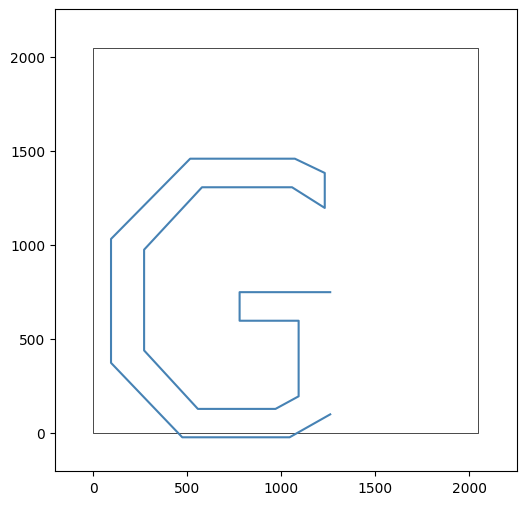

In [105]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# plot contours
em = head.units_per_em
fig, ax = plt.subplots(figsize=(6, 6))
padding = em * 0.1  # 10% padding
ax.set_xlim(-padding, em + padding)
ax.set_ylim(-padding, em + padding)
ax.set_aspect('equal')

# Show em square
ax.add_patch(patches.Rectangle((0, 0), em, em, linewidth=0.5, edgecolor='black', facecolor='none'))

for contour in glyph.contours:
    xs, ys = contour_coords(contour)
    ax.plot(xs, ys, color='steelblue')
    fig.close()

    on_xs  = [p.x for p in contour.points if p.on_curve]
    on_ys  = [p.y for p in contour.points if p.on_curve]
    off_xs = [p.x for p in contour.points if not p.on_curve]
    off_ys = [p.y for p in contour.points if not p.on_curve]
    ax.scatter(on_xs,  on_ys,  color='steelblue')
    ax.scatter(off_xs, off_ys, color='orange')

# Grid
ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', linewidth=0.4, alpha=0.4)

ax.set_title(f"Control Points for '{character}'")

plt.tight_layout()
plt.show()

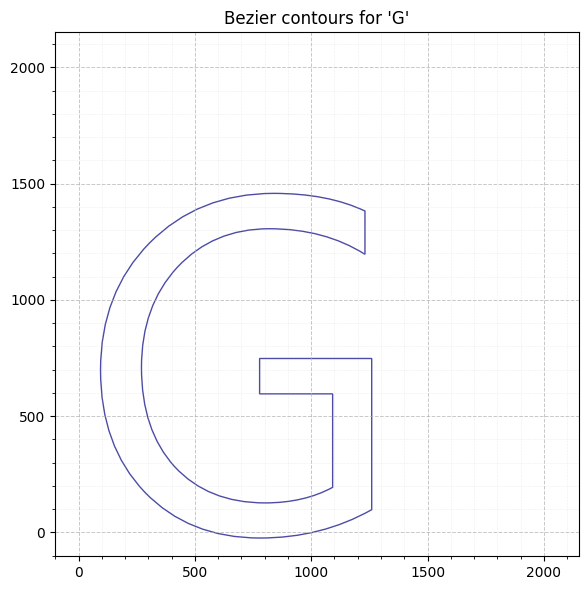

In [103]:
from matplotlib.path import Path
import matplotlib.patches as patches
import matplotlib.pyplot as plt


def expand_contour(contour: Contour) -> list[Point]:  # type: ignore[name-defined]
    """Insert implied on-curve midpoints between consecutive off-curve points."""
    points = list(contour.points)
    result = []
    n = len(points)
    for i in range(n):
        p = points[i]
        result.append(p)
        next_p = points[(i + 1) % n]
        if not p.on_curve and not next_p.on_curve:
            mid = Point((p.x + next_p.x) / 2, (p.y + next_p.y) / 2, True)  # type: ignore[name-defined]
            result.append(mid)
    return result


def contour_to_path(contour: Contour) -> Path:  # type: ignore[name-defined]
    points = expand_contour(contour)
    n = len(points)

    # Rotate so we start at the first on-curve point
    start = next((i for i, p in enumerate(points) if p.on_curve), 0)
    points = points[start:] + points[:start]

    verts = [(points[0].x, points[0].y)]
    codes = [Path.MOVETO]

    i = 1
    while i < n:
        p = points[i % n]
        if p.on_curve:
            verts.append((p.x, p.y))
            codes.append(Path.LINETO)
            i += 1
        else:
            # Quadratic bezier: off-curve control point + on-curve endpoint
            p_off = points[i % n]
            p_on  = points[(i + 1) % n]
            verts += [(p_off.x, p_off.y), (p_on.x, p_on.y)]
            codes += [Path.CURVE3, Path.CURVE3]
            i += 2

    verts.append((0, 0))
    codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)


fig, ax = plt.subplots(figsize=(6, 6))
em = head.units_per_em
pad = em * 0.05
ax.set_xlim(-pad, em + pad)
ax.set_ylim(-pad, em + pad)
ax.set_aspect('equal')

for contour in glyph.contours:
    path = contour_to_path(contour)
    patch = patches.PathPatch(path, facecolor='none', edgecolor='navy', alpha=0.7)
    ax.add_patch(patch)

ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', linewidth=0.4, alpha=0.4)
ax.set_title(f"Bezier contours for '{character}'")
plt.tight_layout()
plt.show()
